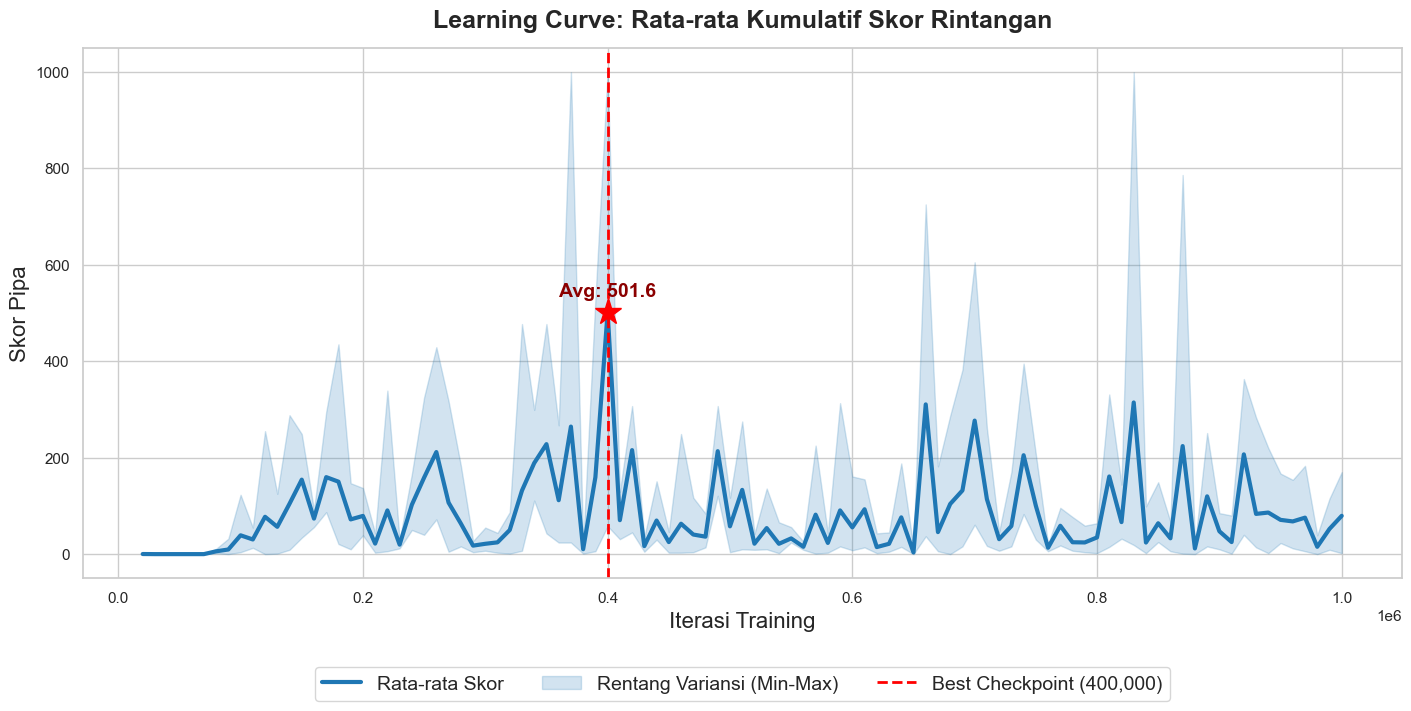

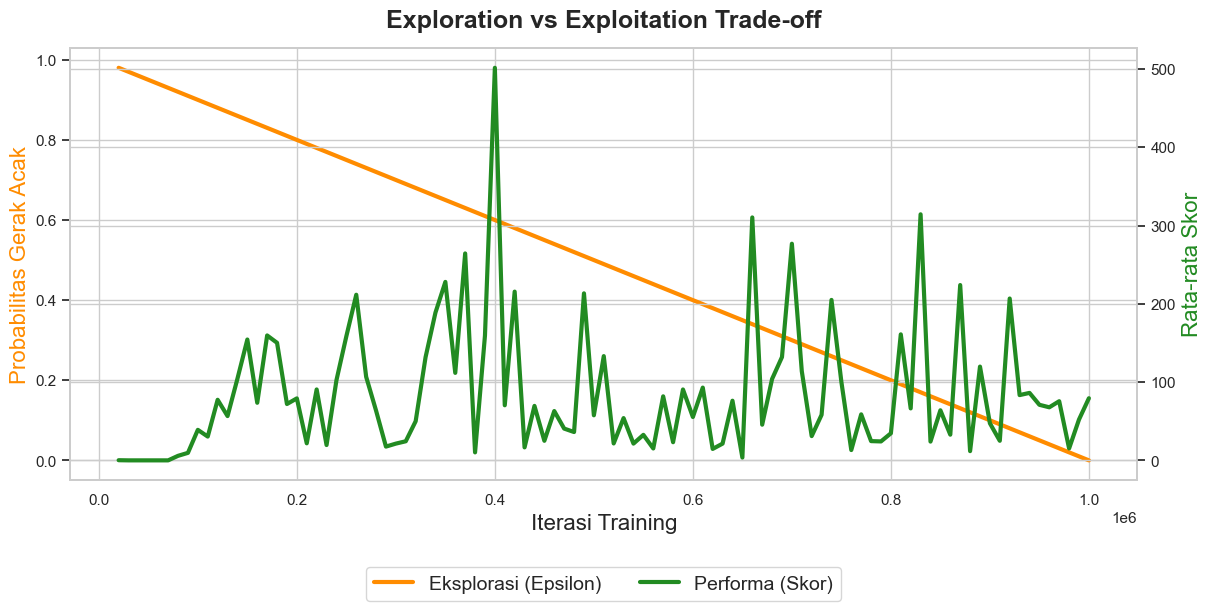

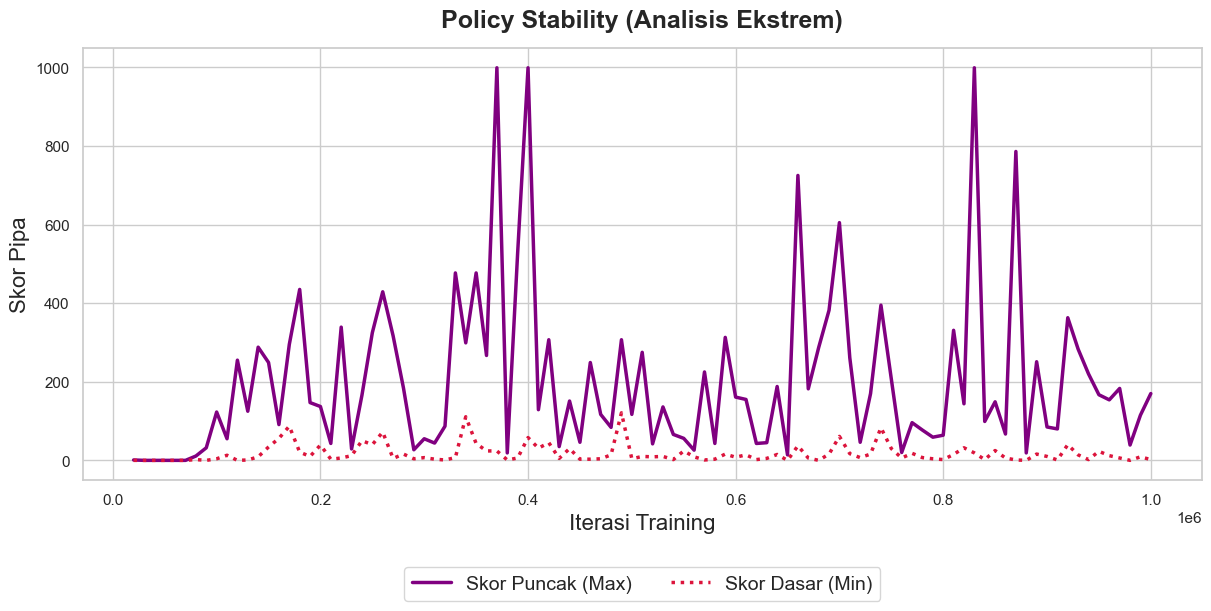

✅ Tiga gambar grafik berhasil disimpan secara terpisah dan rapi!


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. BACA DATA CSV & PERSIAPAN
try:
    df = pd.read_csv('laporan_performa_flappybird.csv')
except FileNotFoundError:
    print("Error: File laporan_performa_flappybird.csv tidak ditemukan.")
    exit()

MAX_ITER = 1000000
df['Epsilon'] = 1.0 - (df['Iterasi Checkpoint'] / MAX_ITER) * (1.0 - 0.0001)
df['Epsilon'] = df['Epsilon'].clip(lower=0.0001)

best_idx = df['Rata-rata Skor'].idxmax()
best_row = df.loc[best_idx]
best_iter = int(best_row['Iterasi Checkpoint'])

# Pengaturan Font Global yang Rapih
plt.rcdefaults()
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'axes.titlesize': 18, 'legend.fontsize': 14})

# ==============================================================================
# GRAFIK 1: LEARNING CURVE (UKURAN 14x7)
# ==============================================================================
plt.figure(figsize=(14, 7), constrained_layout=True)
ax1 = plt.gca()

sns.lineplot(x='Iterasi Checkpoint', y='Rata-rata Skor', data=df, color='#1f77b4', linewidth=3, label='Rata-rata Skor')
ax1.fill_between(df['Iterasi Checkpoint'], df['Skor Terendah'], df['Skor Tertinggi'], color='#1f77b4', alpha=0.2, label='Rentang Variansi (Min-Max)')
ax1.axvline(x=best_iter, color='red', linestyle='--', linewidth=2, label=f'Best Checkpoint ({best_iter:,})')

# Bintang dan Teks
ax1.plot(best_iter, best_row['Rata-rata Skor'], marker='*', color='red', markersize=20)
offset_y = df['Rata-rata Skor'].max() * 0.05
ax1.text(best_iter, best_row['Rata-rata Skor'] + offset_y, f"Avg: {best_row['Rata-rata Skor']:.1f}", color='darkred', ha='center', va='bottom', fontweight='bold')

ax1.set_title('Learning Curve: Rata-rata Kumulatif Skor Rintangan', fontweight='bold', pad=15)
ax1.set_ylabel('Skor Pipa')
ax1.set_xlabel('Iterasi Training')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

plt.savefig('Grafik_1_LearningCurve.png', dpi=300, bbox_inches='tight')
plt.show() # Reset kanvas

# ==============================================================================
# GRAFIK 2: EPSILON VS SKOR (UKURAN 12x6)
# ==============================================================================
plt.figure(figsize=(12, 6), constrained_layout=True)
ax2 = plt.gca()
ax2_twin = ax2.twinx()

sns.lineplot(x='Iterasi Checkpoint', y='Epsilon', data=df, color='darkorange', linewidth=3, ax=ax2, label='Eksplorasi (Epsilon)')
sns.lineplot(x='Iterasi Checkpoint', y='Rata-rata Skor', data=df, color='forestgreen', linewidth=3, ax=ax2_twin, label='Performa (Skor)')

ax2.set_title('Exploration vs Exploitation Trade-off', fontweight='bold', pad=15)
ax2.set_ylabel('Probabilitas Gerak Acak', color='darkorange')
ax2_twin.set_ylabel('Rata-rata Skor', color='forestgreen')
ax2.set_xlabel('Iterasi Training')

lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)
if ax2_twin.get_legend(): ax2_twin.get_legend().remove()

plt.savefig('Grafik_2_Epsilon.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# GRAFIK 3: POLICY STABILITY (UKURAN 12x6)
# ==============================================================================
plt.figure(figsize=(12, 6), constrained_layout=True)
ax3 = plt.gca()

sns.lineplot(x='Iterasi Checkpoint', y='Skor Tertinggi', data=df, color='purple', linestyle='-', linewidth=2.5, label='Skor Puncak (Max)')
sns.lineplot(x='Iterasi Checkpoint', y='Skor Terendah', data=df, color='crimson', linestyle=':', linewidth=2.5, label='Skor Dasar (Min)')

ax3.set_title('Policy Stability (Analisis Ekstrem)', fontweight='bold', pad=15)
ax3.set_ylabel('Skor Pipa')
ax3.set_xlabel('Iterasi Training')
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

plt.savefig('Grafik_3_Stability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tiga gambar grafik berhasil disimpan secara terpisah dan rapi!")

In [29]:
# ==========================================
# GENERATE TABEL BEFORE VS AFTER UNTUK LAPORAN
# ==========================================
awal = df.iloc[0]
akhir = df.loc[best_idx]

print("\n" + "="*60)
print("🎯 TABEL PERBANDINGAN: SEBELUM VS SESUDAH TRAINING")
print("="*60)
print(f"| Metrik Evaluasi              | Model Bayi (Iterasi {int(awal['Iterasi Checkpoint']):,}) | Model Dewasa (Iterasi {int(akhir['Iterasi Checkpoint']):,}) |")
print(f"|------------------------------|-------------------------------|--------------------------------|")
print(f"| Rata-rata Skor Kesuksesan    | {awal['Rata-rata Skor']:.1f}                           | {akhir['Rata-rata Skor']:.1f}                          |")
print(f"| Rekor Skor Tertinggi         | {int(awal['Skor Tertinggi'])}                             | {int(akhir['Skor Tertinggi'])}                            |")
print(f"| Skor Terburuk (Kecelakaan)   | {int(awal['Skor Terendah'])}                             | {int(akhir['Skor Terendah'])}                              |")
print(f"| Tingkat Gerak Acak (Epsilon) | ~{awal['Epsilon']*100:.0f}% (Eksplorasi)           | ~{akhir['Epsilon']*100:.2f}% (Eksploitasi)      |")
print(f"| Status Pengetahuan           | Neural Network Kosong         | Telah Konvergen (Optimized)    |")
print("="*60)
print("💡 Gambar 'Dashboard_Analisis_DRL.png' berhasil dibuat di folder proyek!")


🎯 TABEL PERBANDINGAN: SEBELUM VS SESUDAH TRAINING
| Metrik Evaluasi              | Model Bayi (Iterasi 20,000) | Model Dewasa (Iterasi 400,000) |
|------------------------------|-------------------------------|--------------------------------|
| Rata-rata Skor Kesuksesan    | 0.2                           | 501.6                          |
| Rekor Skor Tertinggi         | 1                             | 999                            |
| Skor Terburuk (Kecelakaan)   | 0                             | 58                              |
| Tingkat Gerak Acak (Epsilon) | ~98% (Eksplorasi)           | ~60.00% (Eksploitasi)      |
| Status Pengetahuan           | Neural Network Kosong         | Telah Konvergen (Optimized)    |
💡 Gambar 'Dashboard_Analisis_DRL.png' berhasil dibuat di folder proyek!
